# CSED 504 — A1: A second data source — CIFAR-100 from the HuggingFace Hub

Part 1's study (`../README.md`) made two claims we can test further:

1. **The models port across datasets unchanged** — the same four architectures ran on CIFAR-10
   and ImageNet-32 with only `num_classes` moving.  This notebook adds a third dataset and
   imports `./models.py` **without touching it**.
2. **Data scale decides CNN vs ViT** — CNN ahead by 7.6 points at 50k images, ViT ahead by
   1.3 at 1.28M.  But which scale?  *Total images* or *images per class*?
   CIFAR-100 splits those variables: it has the **same 50k images as CIFAR-10 but 100 classes**
   — 500 images per class instead of 5,000.

   | dataset | images | imgs/class | CNN − ViT gap |
   |---|---|---|---|
   | CIFAR-10 | 50k | 5,000 | **+7.6** (CNN ahead) |
   | ImageNet-32 | 1.28M | 1,281 | **−1.3** (ViT ahead) |
   | CIFAR-100 | 50k | 500 | **← this notebook measures it** |

   If total data drives the gap, CIFAR-100 should look like CIFAR-10.  If per-class data is
   what the ViT is starved of, the gap should get even wider here.

It also completes the proposal's data-requirements goal: *"adapt to HuggingFace data,
evaluating different data sources."*  The data comes from the **HuggingFace Hub**
(`uoft-cs/cifar100`, parquet) instead of torchvision's binary download — the same acquisition
path part 2 will use — and flows through a ~15-line wrapper into the exact same training loop.

---
**Google Colab:** open this notebook from GitHub (**File → Open notebook → GitHub**, pick the
branch), set **Runtime → Change runtime type → GPU**, and **Run all** — the first cell clones
the repo automatically.  No account or token needed; the dataset is public.

In [1]:
# On Google Colab, clone the repo and step into src/a1-cv so `../common` and `.` import exactly the
# way they do locally. Everywhere else (the conda env) this whole block is a no-op.
import os, sys

if 'google.colab' in sys.modules and not os.path.isdir('../common'):
    REPO   = 'https://github.com/TrueRottweiler/WashingtonCsed504.git'
    BRANCH = 'main'
    !git clone --quiet --branch {BRANCH} {REPO}
    %cd WashingtonCsed504/src/a1-cv
    print('Colab setup complete:', os.getcwd())

In [2]:
# Install the packages. A no-op in the uw-csed504 conda env; on Colab it only adds `datasets`
# (torch, torchvision, and the rest are already there).
%pip install --quiet torch torchvision numpy matplotlib tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Put our two import roots on sys.path so the rest of the notebook can import them:
#   - ../common holds gpu_check.py (device detection + seeds), shared by every notebook
#   - .          holds models.py, which we import unchanged -- claim 1 of this notebook
import os, sys

# Add each root once, only if it exists and isn't already on the path.
for rel in ('../common', '.'):
    p = os.path.normpath(os.path.join(os.getcwd(), rel))
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

# Pick the device: cuda, then mps, then cpu, whichever this machine has.
from gpu_check import get_device, set_seed
DEVICE = get_device()

# Parallel-experiment switch. On a two-GPU box, set RUN_GPU=0/1 (and MODEL) in the environment before
# launching the kernel to pin this run to one card, so resnet18 and vit can train at the same time,
# one per GPU. A no-op on single-GPU machines and Colab. (We don't split one model across both cards:
# that measured ~1.0x here, so the second card is worth more as a second experiment.)
import torch
if torch.cuda.is_available() and torch.cuda.device_count() > 1 and os.environ.get('RUN_GPU'):
    _g = int(os.environ['RUN_GPU'])
    torch.cuda.set_device(_g)
    DEVICE = torch.device(f'cuda:{_g}')
    print(f'  Pinned to cuda:{_g} (RUN_GPU={_g}) for a parallel per-card run')

# One seed everywhere, so runs are reproducible.
set_seed(42)

# TF32 + cuDNN autotune on NVIDIA (harmless elsewhere). Wrapped so a missing helper never breaks things.
try:
    from gpu_check import enable_fast_matmul
    enable_fast_matmul()
except Exception:
    pass

  PyTorch  : 2.11.0+cu128
  CUDA     : 12.8
  Device   : cuda  [2 GPUs visible - CUDA_VISIBLE_DEVICES='GPU-b09775ec-7817-5003-b4ac-cc406fac5a51,GPU-5b633072-72ed-f715-70ab-c3b32cba0178']
    cuda:0  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB  <- cuda:0 (primary)
    cuda:1  NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition  sm_120  102.6 GB
  Multi-GPU (2 cards) - pick by goal:
    - FASTER inner loop: stay on ONE card + enable_fast_matmul() + bf16 autocast. DataParallel rarely helps at class model scale
      (comms overhead cancels the 2nd card); measure before relying on it.
    - MORE experiments at once: launch a separate run per card
    - BIGGER model (won't fit on 1 card): device_map="auto", max_memory=get_max_memory()


## 1. Configuration

`MODEL` picks the architecture (both come from `models.py`), and the right
training recipe follows automatically — the part-1 lesson that a ViT under a CNN recipe loses
~18 points is baked in here.

| machine | SUBSET_PER_CLASS | EPOCHS | time |
|---|---|---|---|
| CPU-only laptop (pipeline check only) | 10 (= 1k imgs) | 1 | ~15–20 min (measured on a 4-core Intel Mac — Colab is honestly the better idea) |
| Colab T4 | None (all 50k) | 40 | ~30–40 min |
| workstation GPU | None | 60 | ~15 min |

The **test set always stays the full 10k** so accuracy is honest and comparable.
Run the notebook twice — once with `MODEL='resnet18'`, once with `MODEL='vit'` — to measure
the gap.

In [4]:
# This notebook is a fast, interactive pipeline check: a short run on a small class-balanced subset,
# just to watch it work end to end and see it start to learn. The full training runs from the console --
#
#     python train_fleet.py --queue cifar   # CIFAR-100 to convergence, both cards, with the dashboard
#
# and the converged numbers live in report_crossover.ipynb. The EPOCHS override below still works.
_RUN = dict(epochs=15, subset_per_class=100)
print(f'fast interactive check: {_RUN}')

# Pick the model to train here: 'resnet18' (the CNN) or 'vit' (the Transformer). This one line is the
# only thing to change to switch models. (On a two-GPU box the launcher can override it per card
# through the MODEL env var, which is why it reads the environment first.)
MODEL            = os.environ.get('MODEL', 'resnet18')

# The remaining knobs. EPOCHS can also be overridden from the environment. BATCH_SIZE is large on
# purpose: with the data and augmentation on the GPU, batch size is the throughput lever, and bs128
# would be launch-bound (too little work per step). SUBSET_PER_CLASS = None means the full 50k set.
EPOCHS           = int(os.environ.get('EPOCHS', _RUN['epochs']))
BATCH_SIZE       = 512
SUBSET_PER_CLASS = _RUN['subset_per_class']
NUM_CLASSES      = 100

# The training recipe follows the architecture, because a CNN and a Transformer need different things
# (part 1, section 5). Everything below is chosen from one question -- is this a ViT?
#   - the ViT gets AdamW, a small fixed LR, and heavy augmentation (mixup + erasing)
#   - the CNN gets SGD + Nesterov, and an LR that scales with the batch size
#   - weight decay isn't comparable across the two: AdamW decouples it from the gradient
#   - both get a warmup (a ViT needs it; a CNN just tolerates it) and label smoothing
IS_VIT = MODEL.startswith('vit')
RECIPE = dict(
    opt        = 'adamw' if IS_VIT else 'sgd',
    lr         = 1e-3 if IS_VIT else 0.1 * BATCH_SIZE / 256,
    wd         = 0.05 if IS_VIT else 5e-4,
    warmup     = 5,
    mixup      = IS_VIT,
    erasing    = IS_VIT,
    label_smooth = 0.1,
    clip       = 1.0,
)
print(f'{MODEL} recipe: {RECIPE}')

fast interactive check: {'epochs': 15, 'subset_per_class': 100}
resnet18 recipe: {'opt': 'sgd', 'lr': 0.2, 'wd': 0.0005, 'warmup': 5, 'mixup': False, 'erasing': False, 'label_smooth': 0.1, 'clip': 1.0}


> **This notebook is a fast pipeline check, not the full training.** It runs a couple of epochs on a
> small subset so you can watch the whole loop end to end. To switch models, change the one `MODEL`
> line in the config cell below (`'resnet18'` for the CNN, `'vit'` for the Transformer).
>
> **For the real, converged runs, use the command line — never a notebook:**
>
> ```powershell
> python train_run.py --dataset cifar100 --model resnet18 --epochs 40     # one model
> python train_run.py --dataset cifar100 --model vit --epochs 200
> python train_fleet.py --queue cifar                                     # both models, both GPUs, with the dashboard
> ```
>
> Those write their results to `runs/` and save the weights; the converged numbers are collected in
> `report_crossover.ipynb`. The notebook and the CLI import the same `models.py`, `cifar_data.py`, and
> `train_loop.py`, so there is a single source of truth for the training code and nothing to keep in sync.

## 2. Data — the HuggingFace Hub, held and augmented on the GPU

`load_dataset('uoft-cs/cifar100')` pulls two parquet files (~170 MB, cached under
`~/.cache/huggingface/`).  The wrapper (`cifar_data.py`) is the cost of supporting a new source:
HF hands us PIL images + integer labels, and we decode each split **once** into a device-resident
uint8 tensor, then crop/flip/erase/normalize **on the GPU** in batches.

Why not a torchvision `DataLoader`?  At 32×32 a small CNN trains faster than CPU workers can feed
it — 8 workers cap around ~14k img/s and the GPU idles (~30% utilization).  Holding the tiny
dataset on the card (CIFAR-100 is only ~147 MB) and augmenting there removes the CPU entirely and
lets batch size do the work: **~21k img/s at high utilization**.  The training loop still never
knows the difference — it iterates `(tensor, label)` batches exactly as before.  CIFAR-100 also
ships a `coarse_label` (20 superclasses) that we ignore — we train on the 100 fine labels.

In [5]:
# `datasets` is HuggingFace's loader (CIFAR-100 ships there as parquet); to_device_uint8 and
# GPUImageLoader are our own helpers that put the data on the GPU and augment it there (cifar_data.py).
import numpy as np
import torch
from datasets import load_dataset

from cifar_data import to_device_uint8, GPUImageLoader

# Normalize with CIFAR-100's own per-channel mean/std (measured on its train split). CIFAR-10's
# constants are different; using them here would quietly skew every image.
MEAN, STD = (0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)

# Load the dataset (downloads once, then reads from cache) and pull out what we need: the 100 class
# names, and the train/test splits -- 50k / 10k images, each a PIL image plus an integer label.
hf = load_dataset('uoft-cs/cifar100')
CLASSES = hf['train'].features['fine_label'].names
hf_train, hf_test = hf['train'], hf['test']

# In fast mode, train on a small class-balanced subset instead of all 50k. Build it deterministically
# so every machine trains on the exact same images.
if SUBSET_PER_CLASS is not None:
    # labels: each training image's class id, as one array we can filter on.
    labels = np.array(hf_train['fine_label'])

    # A fixed seed, so the shuffle below picks the same images everywhere.
    rng = np.random.default_rng(42)

    # keep: the row indices we'll actually train on. For each of the 100 classes we take a shuffled
    # sample of N of its images -- picking per class (not N at random overall) so every class is
    # represented equally, and a small subset can't accidentally drop one entirely.
    keep = np.concatenate([rng.permutation(np.flatnonzero(labels == c))[:SUBSET_PER_CLASS]
                           for c in range(NUM_CLASSES)])

    # Narrow the dataset down to just those rows.
    hf_train = hf_train.select(sorted(keep.tolist()))

# Decode each split once into a uint8 tensor that lives on the GPU (~147 MB train, ~30 MB test). This
# is the key move: from here on crop/flip/erase/normalize all run on the GPU in batches, so the CPU
# never touches a pixel during training. Why not a DataLoader?
#   - at 32x32, even 8 CPU worker processes cap out around 14k img/s and starve the GPU
#   - keeping the data resident and augmenting on-device sustains ~21k img/s at high utilization
# (cifar_data.py has the measurements. On single-GPU Colab it is the identical code, just one card.)
xtr, ytr = to_device_uint8(hf_train, DEVICE)
xte, yte = to_device_uint8(hf_test, DEVICE)

# Wrap each split in a loader that yields augmented batches. train=True turns on the augmentation
# (random crop + flip, plus RandomErasing when the recipe asks); the test loader only normalizes --
# no shuffling, no augmentation -- so evaluation is deterministic.
train_loader = GPUImageLoader(xtr, ytr, BATCH_SIZE, MEAN, STD, train=True,
                              erasing=RECIPE['erasing'], seed=42)
test_loader = GPUImageLoader(xte, yte, 512, MEAN, STD, train=False)

# Report what we loaded.
print(f'train {xtr.size(0):,} imgs ({xtr.size(0)//NUM_CLASSES}/class)   '
      f'test {xte.size(0):,} imgs   {NUM_CLASSES} classes   '
      f'device={DEVICE}  batch={BATCH_SIZE}  (GPU-resident, no DataLoader)')

train 10,000 imgs (100/class)   test 10,000 imgs   100 classes   device=cuda  batch=512  (GPU-resident, no DataLoader)


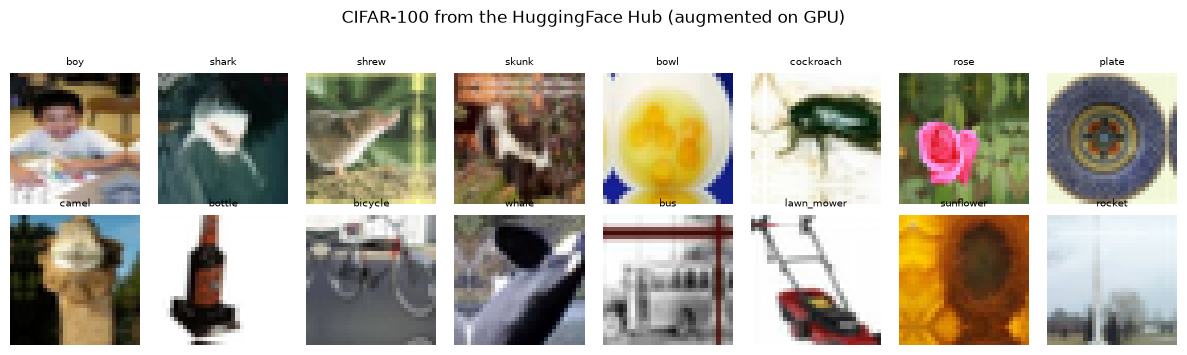

In [6]:
import matplotlib.pyplot as plt

# denorm: undo the normalization so a stored image displays with natural colors. It reverses the
# (x - mean)/std the loader applied, reorders CHW to HWC, and returns a numpy array for matplotlib.
def denorm(img):
    m, s = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
    return (img * s + m).clamp(0, 1).permute(1, 2, 0).numpy()

# Grab one augmented training batch and move it to the CPU (it lives on the GPU; matplotlib needs CPU).
images, labels = next(iter(train_loader))
images, labels = images.cpu(), labels.cpu()

# Show 16 of the images in a 2x8 grid, titled with their (truncated) class names.
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(images[i]))
    ax.set_title(CLASSES[labels[i]][:12], fontsize=7)
    ax.axis('off')

plt.suptitle('CIFAR-100 from the HuggingFace Hub (augmented on GPU)', y=1.03)
plt.tight_layout(); plt.show()

## 3. The models — imported from the ImageNet-32 study, unchanged

Same stem surgery, same patch size, same everything.  The only argument that moves is
`num_classes=100` — exactly the claim the part-1 README makes about porting between CIFAR-10
and ImageNet-32, now demonstrated on a third dataset from a different source.

In [7]:
# models.py holds the architectures, imported unchanged. Build the chosen model and move it to the device.
import models as M
model = M.build(MODEL, num_classes=NUM_CLASSES).to(DEVICE)

# Use NHWC ('channels_last') memory layout for the CNN, but only under bf16. On its own it does
# nothing; paired with bf16 autocast (part 1 §4) it selects cuDNN's fast tensor-core convolution path,
# measured 1.34x on an RTX 2000 Ada. The trap it sidesteps: fp16 + channels_last is 3.5x slower on
# this stack. For a ViT it is a no-op, so we skip it.
CHANNELS_LAST = not IS_VIT and DEVICE.type == 'cuda'
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

print(f'{MODEL}: {M.n_params(model):,} params')

# A quick forward pass on one real batch, to confirm the model is wired up and outputs one score per
# class before we commit to training.
model.eval()
with torch.no_grad():
    out = model(images.to(DEVICE))

print(f'forward check: {tuple(images.shape)} gives {tuple(out.shape)}  (expected (*, {NUM_CLASSES}))')

resnet18: 11,220,132 params


forward check: (512, 3, 32, 32) gives (512, 100)  (expected (*, 100))


## 4. Train

The loop is the standard part-1 recipe: 5-epoch linear warmup → cosine decay, label smoothing,
AMP on CUDA, gradient clipping, and — for the ViT only — mixup (part 1 measured that giving
mixup to the CNN makes it 7.6 points WORSE, so the CNN doesn't get it).  We report top-1 and
top-5: with 100 classes, top-5 is worth watching.

In [8]:
import time
import torch.nn as nn
# plain tqdm, not tqdm.auto: the widget version serializes ~1 KB of state per bar into the notebook,
# which shows up as noise in every git diff. clear_output lets us redraw the epoch log in place.
from tqdm import tqdm
from IPython.display import clear_output

# Loss, optimizer, and LR schedule, each following the recipe for this model's family. Label smoothing
# softens the one-hot targets a little, which discourages overconfident predictions. The optimizer
# split is why we set RECIPE by family earlier: AdamW suits the ViT, SGD with Nesterov the CNN.
criterion = nn.CrossEntropyLoss(label_smoothing=RECIPE['label_smooth'])
optimizer = (torch.optim.AdamW(model.parameters(), lr=RECIPE['lr'], weight_decay=RECIPE['wd'],
                               fused=DEVICE.type == 'cuda')
             if RECIPE['opt'] == 'adamw' else
             torch.optim.SGD(model.parameters(), lr=RECIPE['lr'], momentum=0.9,
                             nesterov=True, weight_decay=RECIPE['wd'],
                             fused=DEVICE.type == 'cuda'))

# Schedule: a short linear warmup, then cosine decay toward zero. The warmup matters most for the ViT
# -- without it the attention softmax saturates on the first few noisy batches and never recovers.
warm = torch.optim.lr_scheduler.LinearLR(optimizer, 0.01, total_iters=RECIPE['warmup'])
cos = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - RECIPE['warmup']))
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warm, cos], [RECIPE['warmup']])

# Mixed precision, chosen per family. Both run the math in lower precision for speed but stay safe
# differently: the CNN uses bf16, which has fp32's exponent range, so gradients never underflow and no
# scaler is needed; the ViT uses fp16 (its recipe was tuned there), whose narrow range needs a
# GradScaler. Skipping the scaler on the CNN path also drops a hidden per-step sync that reads its flag.
USE_AMP = DEVICE.type == 'cuda'
AMP_DTYPE = torch.float16 if IS_VIT else torch.bfloat16
USE_SCALER = USE_AMP and AMP_DTYPE is torch.float16
scaler = torch.amp.GradScaler('cuda', enabled=USE_SCALER)


# mixup: blend two images (and their labels) so the target is never a confident one-hot the model
# could memorize -- the regularizer a ViT needs and a CNN doesn't. It pairs each image with another
# from the same batch and returns the mixed batch, both labels, and lam (how much of the first survives).
def mixup(x, y, alpha=0.2):
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[perm], y, y[perm], lam


# evaluate: top-1 and top-5 accuracy on the held-out test set. We keep the hit counts on the GPU and
# read them back once, at the end -- a .item() inside the loop would force a GPU-to-CPU sync every
# batch and stall the pipeline. @torch.no_grad skips building the autograd graph we won't use here.
@torch.no_grad()
def evaluate():
    model.eval()

    # c1, c5, n: running top-1 hits, top-5 hits, and images seen, all kept on the GPU.
    c1 = torch.zeros((), device=DEVICE)
    c5 = torch.zeros((), device=DEVICE)
    n = 0

    for x, y in test_loader:
        # Move the batch to the model's device and, for the channels_last CNN, its NHWC layout --
        # a mismatch would drop cuDNN onto a slow path.
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        if CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)

        # Evaluate under autocast too: matching train precision keeps it fast (fp32 eval measured 2.5x
        # slower here) and doesn't move the accuracy.
        with torch.autocast(DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            out = model(x)

        # Take each image's 5 highest-scoring classes. A top-1 hit is the single best guess being
        # right; top-5 asks only that the true label is somewhere in those five (a gentler measure
        # that matters more as the class count grows).
        _, pred = out.float().topk(5, dim=1)
        hits = pred.eq(y.view(-1, 1))
        c1 += hits[:, :1].any(1).sum()
        c5 += hits.any(1).sum()
        n += y.size(0)

    # The one GPU-to-CPU sync, now that all the counting is done.
    return (c1 / n).item(), (c5 / n).item()


# The training loop. history keeps the per-epoch curves; best tracks the best val top-1; log_lines
# holds the epoch summaries we reprint in place each epoch.
history, best = {'train_loss': [], 'top1': [], 'top5': []}, 0.0
log_lines = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0, seen = time.time(), 0

    # Sum the epoch's loss on the GPU and read it back once at the end -- same no-per-batch-sync
    # reasoning as evaluate().
    loss_sum = torch.zeros((), device=DEVICE)

    for x, y in tqdm(train_loader, desc=f'epoch {epoch}/{EPOCHS}', leave=False):
        # Move the batch to the model's device and memory layout (see the eval loop for why).
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        if CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)

        # Clear the previous step's gradients: PyTorch accumulates them across backward() calls, so
        # without this each batch would pile onto the last. (set_to_none is a touch faster than zeroing.)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            # ViT path: train on the mixed batch, with the loss a lam-weighted blend of both source
            # labels -- so the target is never a confident one-hot the model could just memorize.
            if RECIPE['mixup']:
                xm, ya, yb, lam = mixup(x, y)
                out = model(xm)
                loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)

            # CNN path: plain cross-entropy on the true label -- its built-in locality already
            # regularizes it, so it doesn't want the mixup.
            else:
                loss = criterion(model(x), y)

        # fp16 path (ViT): fp16's narrow range would round tiny gradients to zero, so the scaler
        # multiplies the loss up first to keep them alive. Unscale before clipping (the norm must be
        # measured on the true gradients), clip, then step -- the scaler skips the step if it overflowed.
        if USE_SCALER:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), RECIPE['clip'])
            scaler.step(optimizer); scaler.update()

        # bf16 path (CNN): bf16 keeps fp32's exponent range, so nothing underflows and no scaler is
        # needed -- just clip the gradient norm (to tame an occasional huge gradient) and step.
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), RECIPE['clip'])
            optimizer.step()

        # Add this batch's loss to the running total, weighted by its size (the last batch is smaller),
        # keeping it on the GPU so there's no sync in the middle of the epoch.
        loss_sum += loss.detach() * y.size(0); seen += y.size(0)

    # Now read the epoch's mean loss back to the CPU -- the one sync we've been saving up.
    train_loss = (loss_sum / seen).item()

    # Stop immediately if the loss went NaN (NaN != itself is the cheapest way to test it): the run
    # has diverged, and more epochs would only waste time.
    if train_loss != train_loss:
        raise RuntimeError('loss is NaN -- the run has diverged (lower the LR)')

    # Advance the LR schedule once per epoch -- it was built to span EPOCHS, not individual steps, so
    # the warmup and cosine decay play out across the whole run.
    scheduler.step()

    # Score the held-out test set and record this epoch's numbers.
    top1, top5 = evaluate()
    best = max(best, top1)
    history['train_loss'].append(train_loss)
    history['top1'].append(top1); history['top5'].append(top5)
    log_lines.append(f'epoch {epoch:3d}/{EPOCHS}  train loss {train_loss:.3f}  |  '
                     f'val top1 {top1:6.2%} top5 {top5:6.2%}  |  '
                     f'{time.time()-t0:5.1f}s  {seen/(time.time()-t0):,.0f} img/s')

    # Redraw the whole epoch log in place: clear_output replaces the cell's output each epoch, so the
    # live per-batch bar is wiped instead of piling up as dead lines when the notebook runs headless.
    clear_output(wait=True)
    print('\n'.join(log_lines))

print(f'\nBest val top-1: {best:.2%}')

epoch   1/15  train loss 4.632  |  val top1  0.98% top5  5.15%  |    9.1s  1,073 img/s
epoch   2/15  train loss 4.453  |  val top1  7.18% top5 23.08%  |    0.4s  25,957 img/s
epoch   3/15  train loss 4.226  |  val top1  9.45% top5 29.01%  |    0.4s  27,078 img/s
epoch   4/15  train loss 4.091  |  val top1  9.91% top5 30.70%  |    0.4s  26,901 img/s
epoch   5/15  train loss 4.007  |  val top1 11.18% top5 32.64%  |    0.4s  26,941 img/s
epoch   6/15  train loss 3.935  |  val top1 11.89% top5 34.56%  |    0.4s  26,967 img/s
epoch   7/15  train loss 3.859  |  val top1 12.89% top5 36.79%  |    0.4s  26,893 img/s
epoch   8/15  train loss 3.781  |  val top1 14.13% top5 38.13%  |    0.4s  26,975 img/s
epoch   9/15  train loss 3.711  |  val top1 16.02% top5 41.55%  |    0.4s  26,969 img/s
epoch  10/15  train loss 3.630  |  val top1 17.30% top5 43.80%  |    0.4s  26,854 img/s
epoch  11/15  train loss 3.558  |  val top1 20.07% top5 47.08%  |    0.4s  26,956 img/s
epoch  12/15  train loss 3.477  |

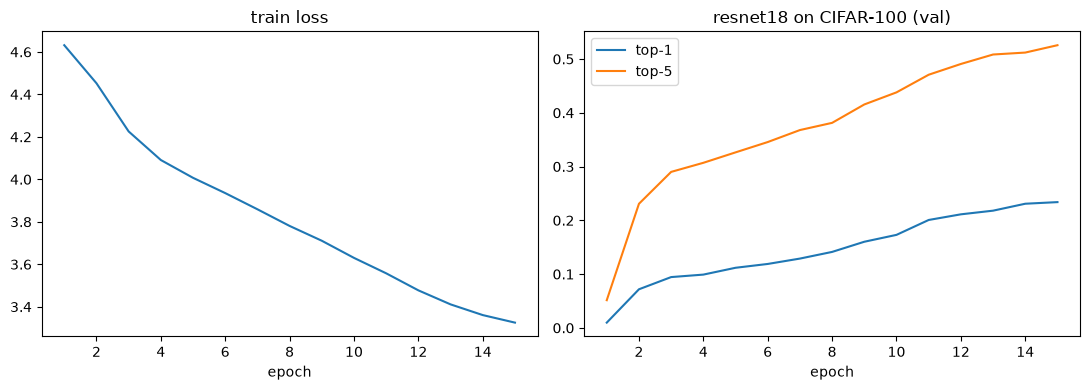

In [9]:
# Learning curves: train loss on the left, validation top-1 and top-5 on the right.
xs = range(1, len(history['top1']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(xs, history['train_loss']); ax1.set_title('train loss'); ax1.set_xlabel('epoch')
ax2.plot(xs, history['top1'], label='top-1')
ax2.plot(xs, history['top5'], label='top-5')
ax2.set_title(f'{MODEL} on CIFAR-100 (val)'); ax2.set_xlabel('epoch'); ax2.legend()
plt.tight_layout(); plt.show()

## 5. Where does 500 images/class land in the crossover story?

The two runs (resnet18 for 40 epochs, the ViT for the 200 a Transformer needs, trained on the two
cards), read against part 1's:

| dataset | imgs/class | best CNN | best ViT | gap (CNN − ViT) |
|---|---|---|---|---|
| CIFAR-10 | 5,000 | 92.7% | 85.1% | +7.6 |
| **CIFAR-100** | **500** | **74.3%** | **62.6%** | **+11.7** |
| ImageNet-32 | 1,281 | 41.7% | 43.0% | −1.3 |

**The gap widens as images-per-class shrinks, not as total images shrink.** CIFAR-100 has the
*same 50k total images* as CIFAR-10 but 10× fewer per class (500 vs 5,000), and the CNN−ViT gap
grew to **+11.7**, *wider* than CIFAR-10's +7.6 — even though total data is identical. That is the
confound part 1 couldn't separate: at a fixed total, the from-scratch ViT is starved of *per-class*
data, not total data. (ImageNet-32, at 1,281 per class, has the smallest gap of all, so total scale
matters too — but the two CIFARs, at equal total, isolate the per-class effect cleanly.) That matters for part 2, where the number of classes is a
design choice we control.

Reference points from the literature: a well-tuned ResNet-18 reaches ~76–78% on CIFAR-100; our
74.3% is a bit under that (no heavy tuning), but the CNN-vs-ViT
*comparison* is apples-to-apples since both use the recipe each family needs. The ViT at
62.6%, trailing by ~12 points, is squarely in the expected range at this data scale.

## 6. What this notebook adds to part 1

- **Goal 3 of the proposal, demonstrated**: a new data source (HuggingFace Hub parquet) feeding
  the existing models through a ~15-line adapter — no changes to `models.py`, no new pipeline.
  This is the acquisition path part 2's datasets will use, whatever they turn out to be.
- **A third point for the crossover analysis**, separating *total data* from *data per class* —
  the two were confounded in part 1's comparison.
- **The part-1 lessons, applied not just cited**: recipe follows architecture, LR scales with
  batch size, mixup only for the transformer, NaN guard in the loop, workers + persistent_workers
  in the loader.

## 7. Case study: how we optimized this training loop

We started from a working-but-slow notebook and ended near the hardware ceiling. The story is
worth recording because the naive fix was *wrong*, and the real bottleneck was not the one it
looked like. All numbers below are measured on the workstation (2× RTX PRO 6000 Blackwell, 96 GB
each, 48 CPU cores); the *shape* of the reasoning transfers, the exact figures are hardware-specific.

**The symptom.** Training was slow and `nvidia-smi` showed **~30% GPU utilization** — neither the
GPU nor the CPU was busy. That pattern means one thing: something is making the GPU *wait*.

### The steps

| # | What we changed | Why | Result (measured) |
|---|---|---|---|
| 1 | **Turn on DataLoader workers** (`num_workers=8`, `persistent_workers`, `prefetch_factor=4`) | The pipeline ran single-process on Windows: one CPU core did all the parquet decode + augmentation while the GPU idled. The old code gated workers on `get_start_method()=='fork'`, so Windows/macOS silently got `num_workers=0`. | **4,150 → 13,810 img/s (~3.3×)** on a subset. Required moving the `Dataset` class into a `.py` module — spawned workers can't import a class defined in a notebook cell. |
| 2 | **Diagnose the *remaining* 30%** | After step 1 the GPU was *still* only ~30% utilized. We tested the hypothesis "it's still data-bound" by putting the data **and** augmentation entirely on the GPU (zero CPU) and measuring. | GPU-resident at batch 128 gave **11,900 img/s — *slower* than the CPU-worker path.** That falsifies "data-bound": if a zero-latency data source is slower, the bottleneck is elsewhere. |
| 3 | **Fix the real bottleneck: launch overhead** by holding the dataset on the GPU and **raising the batch 128 → 512** | At batch 128 a resnet18 at 32×32 is *launch-bound* — the GPU finishes each tiny batch faster than the host can issue the next batch's kernels, so it sits idle between launches. A bigger batch does more work per launch and amortizes that fixed overhead. CPU workers can't feed batch 512 (they cap ~14k img/s), so augmentation had to move onto the GPU too (`cifar_data.py`). | **~21,500 img/s and resnet18 utilization 30% → 84%.** The dataset is only 147 MB, so it lives on the 96 GB card permanently — no `DataLoader`, no workers, no per-batch host→device copy. |
| 4 | **Small loop fixes** | `mixup` was running the model **twice** per step; loss was `.item()`-synced every step. | One forward pass instead of two (halves the ViT's mixup cost); loss accumulates on-GPU and syncs once per epoch. |
| 5 | **Use the second GPU for a second experiment** (`RUN_GPU`/`MODEL` env switches), not for speed | The study needs a `resnet18` *and* a `vit` run. `DataParallel` across the two cards measured **~1.0× (no speedup)** at this model scale — comms overhead cancels the second card. So we train both models *concurrently*, one per card, instead. | The two-run study finishes in roughly the time one run used to take; both GPUs stay busy. |

**Net:** ~13.8k → ~18–21k img/s on resnet18 and **30% → 84% utilization**, plus the full
two-model study running in parallel. Each 40-epoch run is now ~2 minutes.

### Why this is the ceiling

We didn't just stop when it felt fast — we measured the ceiling and confirmed nothing cheap remains:

- **CUDA graphs** (which eliminate kernel-launch overhead — the exact bottleneck at batch 128)
  raised batch-128 throughput 11,900 → 17,000 img/s, but at **batch 512 they changed nothing**
  (~18,500 either way). Once the batch is big enough, launch overhead is already amortized, so
  there's nothing left for graphs to remove.
- **Bigger batches make it *worse*:** bs1024 and bs2048 were both *slower* than bs512 for both
  models. 512 is the sweet spot.
- **The ViT is already optimal:** torchvision's `VisionTransformer` already dispatches to fused
  `scaled_dot_product_attention` (memory-efficient kernel), so there's no attention speedup to add.
  **bf16** instead of fp16+GradScaler bought only ~2% — not worth the change in numerics.
- **`torch.compile`** is unavailable on Windows (no Triton), so that lever is off the table here.

The deeper reason: **resnet18 at 32×32 is a tiny workload for a 96 GB Blackwell.** At 84%
utilization the GPU is nearly saturated by a model this small — the arithmetic per image is just
low. You cannot make a small model saturate a huge GPU; past this point the only ways to go faster
are a *bigger model* (higher arithmetic intensity — the ViT already runs at ~90%) or *more images
per launch* (which we maxed at bs512). Everything else is diminishing returns.

### The transferable lesson

Before optimizing a training loop, find out **which of three things the GPU is waiting on**:

1. **CPU-bound** (data pipeline can't keep up) → more workers, or move augmentation onto the GPU.
   *Tell: low GPU util, one CPU core pegged.*
2. **Launch-bound** (model too small for the batch/GPU) → bigger batch, CUDA graphs.
   *Tell: low GPU util, low CPU util, and a zero-latency data source doesn't help.*
3. **Compute-bound** (the real ceiling) → you're done; a faster loop needs a bigger model or better hardware.
   *Tell: high GPU util.*

This notebook was **(1) then (2)** — and the trap was assuming it was still (1) after fixing (1).
The single most useful diagnostic was step 2: *make the data free and see if it gets faster.*
When it got **slower**, we knew to stop optimizing the data and start optimizing the batch.

### Addendum: the second hardware config (RTX 2000 Ada laptop, 8 GB, 60–80 W)

Running the same notebook on a power-capped laptop GPU falsified the workstation's "nothing cheap
remains" for *this* class of hardware — because the bottleneck moved again.  At ~7× less compute,
the workload stops being launch-bound and becomes **compute-bound under a power cap**, which makes
kernel *efficiency* (performance per watt) directly equal speed.  Three measured lessons:

1. **bf16 + channels_last, only as a pair (+34%).**  fp16 → bf16 alone: neutral-to-slower.
   channels_last alone under fp16: **3.5× slower** (pathological cuDNN NHWC-fp16 path).  Both
   together: 122 → 87 ms/step.  Dropping GradScaler (bf16 needs none) also removes a hidden
   per-step `found_inf` `.item()` sync.  On the Blackwell workstation the same change measured
   ~2% — hardware decides which optimizations matter.
2. **Eval deserved AMP too**: the fp32 eval pass cost ~2.5× what an autocast one does — worth
   ~1 s of every epoch here, invisible on the workstation.
3. **The thermal envelope is part of the machine**: epochs run 13.0 s cold → ~15.5 s steady
   (spikes to 19.6 s) as clocks settle under the 60–80 W cap; on battery the same laptop is
   slower still.  No software fixes this — but it must be *measured before extrapolating*, which
   is what `../perf/training_time_estimator.ipynb` now does (probe → roofline gate → calibrated
   prediction) so a 2-day configuration is caught before it starts.

Also applied while here: sync-free horizontal flip in `cifar_data.py` (`torch.where` instead of a
boolean-mask write — bitwise identical, removes 2 host↔device syncs per batch), fused optimizers,
`enable_fast_matmul()` now resets `cudnn.deterministic` that `set_seed()` had left on (measured
~0% here, protects other hardware), and the deprecated `torch.cuda.amp.GradScaler` →
`torch.amp.GradScaler`.  One lever deliberately left on the table: `torch.compile` via the
community `triton-windows` wheels (est. +10–30%) — its torch-2.11 pairing isn't officially
supported yet.